# Section 1 — Foundations and Traditional Machine Learning

Linear regression, logistic regression, decision trees, and k-means — fit, evaluate, and interpret on two insurance datasets that serve as a common thread throughout Act I.

Part of the EAA seminar *Machine Learning & Generative AI: A Hands-On Guide to Actuarial Practice* by Dr. Simon Hatzesberger (8–9 June 2026, Munich).

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/simonhatzesberger/ml-genai-actuarial-practice/blob/main/notebooks/01_foundations_traditional_ml/01_foundations_traditional_ml.ipynb)

Repository: [simonhatzesberger/ml-genai-actuarial-practice](https://github.com/simonhatzesberger/ml-genai-actuarial-practice) — Code under the [MIT License](https://github.com/simonhatzesberger/ml-genai-actuarial-practice/blob/main/LICENSE).


We train four classical machine learning methods on two real insurance datasets that accompany us throughout the machine learning part:

- **Regression** uses a US **medical-cost** dataset — 1,338 policyholders; the target is the annual medical insurance charge in USD ([Kaggle: mirichoi0218/insurance](https://www.kaggle.com/datasets/mirichoi0218/insurance/data)).
- **Classification** and **unsupervised clustering** use a **car-insurance** dataset — 10,000 drivers; the target is whether the policyholder filed a claim ([Kaggle: sagnik1511/car-insurance-data](https://www.kaggle.com/datasets/sagnik1511/car-insurance-data)).

Copies of both CSV files sit in this notebook's `data/` folder, so nothing has to be downloaded by hand. We fit each model, visualise its decisions where we can (tree diagrams, calibration curves, cluster projections), and interpret the results in plain actuarial language at every step.

## Contents

- [Learning objectives](#learning-objectives)
- [Setup](#setup)
- [1. Regression — predicting medical insurance charges](#1-regression-predicting-medical-insurance-charges)
- [2. Binary classification — predicting car-insurance claims](#2-binary-classification-predicting-car-insurance-claims)
- [3. Clustering — segmenting a car-insurance portfolio](#3-clustering-segmenting-a-car-insurance-portfolio)
- [Exercises](#exercises)
- [Summary](#summary)
- [Next steps](#next-steps)
- [References](#references)


## Learning objectives

By the end of this notebook you will be able to:

- distinguish supervised from unsupervised learning and pick the right framing for an actuarial question;
- recognise the three faces of supervised learning — regression, binary classification, multiclass classification — and pick a suitable error metric for each;
- fit and interpret a linear regression, a logistic regression, and a decision tree on tabular insurance data;
- read a decision-tree diagram — turn an if-then partition into a portfolio narrative;
- read a bias-variance curve and identify the sweet-spot complexity;
- explain why a decision tree miscalibrates probabilities even when its ranking looks fine;
- run k-means with a sensible choice of K and translate centroids back into actuarial language.


## Setup

The cell below detects whether you are running on Google Colab. On Colab it installs the section's pinned dependencies and downloads the two datasets into a local `data/` folder. Running locally instead, it assumes you have already run `pip install -r notebooks/01_foundations_traditional_ml/requirements.txt` and that the two CSV files live in a `data/` subfolder beside this notebook (`data/data_medical_cost.csv` and `data/data_car_insurance.csv`) — which is exactly how they are laid out in the repository.

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q -r https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/01_foundations_traditional_ml/requirements.txt
    !mkdir -p data
    !wget -q -O data/data_medical_cost.csv  https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/01_foundations_traditional_ml/data/data_medical_cost.csv
    !wget -q -O data/data_car_insurance.csv https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/01_foundations_traditional_ml/data/data_car_insurance.csv

SEED = 42

print(f"Setup complete. Environment: {'Colab' if IN_COLAB else 'local'}.")


Setup complete. Environment: local.


A small colour palette and a shared seaborn theme so that every figure in the notebook has a consistent look.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Brand colours reused across every figure in the notebook.
PRIMARY      = "#1F3A6E"
ACCENT_RED   = "#C0504D"
ACCENT_GREEN = "#4E7C59"
GRAY_TEXT    = "#404040"

# Register the palette and a few readable defaults as the global theme.
sns.set_theme(
    style="whitegrid",
    palette=[PRIMARY, ACCENT_RED, ACCENT_GREEN, "#7A8DA8", "#9C7A7A"],
    rc={
        "axes.edgecolor":   GRAY_TEXT,
        "axes.labelcolor":  GRAY_TEXT,
        "xtick.color":      GRAY_TEXT,
        "ytick.color":      GRAY_TEXT,
        "axes.titlecolor":  PRIMARY,
        "axes.titleweight": "bold",
        "grid.color":       "#E5E5E5",
        "figure.facecolor": "white",
        "axes.facecolor":   "white",
    },
)

# Seed NumPy so the few stochastic steps (split, k-means) reproduce.
np.random.seed(SEED)


## 1. Regression — predicting medical insurance charges

Our first task is a regression: predict the **annual medical insurance charge** for a US policyholder from six personal characteristics. A linear model gives us a strong, interpretable baseline; a decision tree then relaxes the linearity assumption and captures interactions automatically.

> **Dataset.** *Medical Cost Personal Datasets* by Choi (2018), hosted on Kaggle ([mirichoi0218/insurance](https://www.kaggle.com/datasets/mirichoi0218/insurance/data)). 1,338 individuals with seven columns: `age`, `sex`, `bmi`, `children`, `smoker`, `region`, and the target `charges` (USD).

In [3]:
# Load the medical-cost CSV and look at the first few rows.
df = pd.read_csv("data/data_medical_cost.csv")
print(f"shape: {df.shape}")
df.head()


shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**A quick read.** Six features, one target (`charges`). Three columns are categorical (`sex`, `smoker`, `region`); the rest are numeric. `charges` is the per-year insurance cost — what an underwriter would want to predict from a new applicant's intake form.


In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


**Reading the summary.**

- `charges` ranges from roughly 1.1k to over 63k USD. The mean (≈ 13.3k USD) sits well above the median (≈ 9.4k USD), so the target is strongly right-skewed.
- `age` covers 18–64, fairly evenly spread.
- `bmi` averages 30.7 — by US clinical thresholds the sample skews towards overweight.
- About 20 % of the sample are smokers; this single binary feature will turn out to dominate the model.

### Three quick EDA pictures

The target distribution, charges by smoker status, and a Spearman correlation heatmap. The point is to *see the problem*, not exhaust the data.


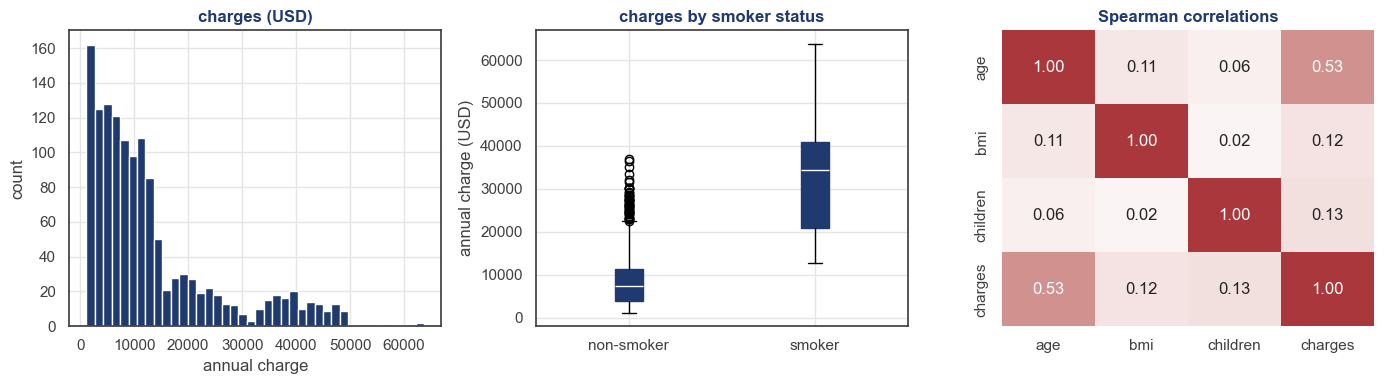

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (1) Target distribution — note the long right tail.
axes[0].hist(df["charges"], bins=40, color=PRIMARY, edgecolor="white")
axes[0].set_title("charges (USD)")
axes[0].set_xlabel("annual charge")
axes[0].set_ylabel("count")

# (2) Charges split by smoker status — the dominant signal.
axes[1].boxplot(
    [df.loc[df["smoker"] == "no",  "charges"],
     df.loc[df["smoker"] == "yes", "charges"]],
    tick_labels=["non-smoker", "smoker"],
    patch_artist=True,
    boxprops=dict(facecolor=PRIMARY, color=PRIMARY),
    medianprops=dict(color="white"),
)
axes[1].set_title("charges by smoker status")
axes[1].set_ylabel("annual charge (USD)")

# (3) Spearman correlations among the numeric columns.
num_cols = ["age", "bmi", "children", "charges"]
sns.heatmap(df[num_cols].corr(method="spearman"),
            annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, ax=axes[2], cbar=False)
axes[2].set_title("Spearman correlations")

fig.tight_layout()
plt.show()


**What the quick EDA tells us.**

- The target is **strongly right-skewed**: most policyholders cost under ≈ 15k USD per year, with a long tail stretching past 60k. A second, smaller group appears around 30–45k USD — almost all of them smokers — but in the raw histogram it reads as a heavy tail rather than a cleanly separated second peak.
- That high-cost tail is **driven by smoking**: the smoker box plot sits in a completely different range from the non-smoker box. This is the single strongest signal in the dataset.
- Among the numeric features, `age` correlates most with `charges` (Spearman ≈ 0.53). `bmi` and `children` each show a weak but non-zero positive Spearman correlation (≈ 0.12 and ≈ 0.13) — comparable to one another and clearly not negligible, so we keep both.

### Train / test split and a tiny metrics helper

Hold out 20 % for the test set and touch it only at the very end. The helper returns RMSE, MAE, and R².

> **Note.** A production-grade workflow would use a validation set (60/20/20) or k-fold cross-validation for hyperparameter selection. We skip that here because we are not tuning anything that would meaningfully change the conclusions.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Separate the target from the features.
target = "charges"
X = df.drop(columns=[target])
y = df[target]

# Hold out 20 % as a test set we touch only at the very end.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

def metrics_table(y_true, y_pred, label="model"):
    return pd.DataFrame(
        {
            "RMSE": [np.round(np.sqrt(mean_squared_error(y_true, y_pred)), 2)],
            "MAE":  [np.round(mean_absolute_error(y_true, y_pred), 2)],
            "R²":   [np.round(r2_score(y_true, y_pred), 3)],
        },
        index=[label],
    )

print(f"train: {X_train.shape}   test: {X_test.shape}")


train: (1070, 6)   test: (268, 6)


### Model A — Linear regression

A linear regression predicts the target as a weighted sum of the features, with the weights chosen to minimise the sum of squared residuals (ordinary least squares):

$$\hat y = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p, \qquad \hat\beta = \arg\min_{\beta} \sum_{i=1}^{n}(y_i - \hat y_i)^2.$$

The three categorical features are one-hot encoded inside a `Pipeline` so we can pass the raw DataFrame straight to `.fit()` and `.predict()`.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# One-hot the categoricals; pass the numeric columns through untouched.
cat_cols = ["sex", "smoker", "region"]
num_cols_reg = ["age", "bmi", "children"]

preprocess = ColumnTransformer([
    ("num", "passthrough",                          num_cols_reg),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

# Bundle pre-processing + model so the whole thing fits in one call.
linear = Pipeline([("preprocess", preprocess), ("lr", LinearRegression())])
linear.fit(X_train, y_train)
y_pred_lr = linear.predict(X_test)

metrics_table(y_test, y_pred_lr, label="linear regression")


,RMSE,MAE,R²
linear regression,5796.28,4181.19,0.784


**Reading the metrics.** R² around 0.78 means the linear model explains roughly 78 % of the variance of `charges` on the held-out test set — strong for a one-line model. The RMSE of about 5.8k USD is the typical out-of-sample error; against a target whose mean is ≈ 13k USD, that is sizeable but workable. MAE (≈ 4.2k USD) sits well below RMSE, which tells us the squared-error penalty is driven by a small number of large misses — exactly what we expect with a right-skewed target.

In [8]:
feature_names_reg = (
    num_cols_reg
    + list(linear.named_steps["preprocess"]
                 .named_transformers_["cat"]
                 .get_feature_names_out(cat_cols))
)
coefs = linear.named_steps["lr"].coef_

# Sort coefficients by absolute size — the biggest price drivers first.

coef_table = (
    pd.DataFrame({"coef (USD)": coefs}, index=feature_names_reg)
      .sort_values("coef (USD)", key=np.abs, ascending=False)
)
coef_table.round(1)


,coef (USD)
smoker_no,-11825.6
smoker_yes,11825.6
region_northeast,459.6
children,425.3
region_southwest,-350.2
bmi,337.1
age,257.0
region_southeast,-198.3
region_northwest,88.9
sex_male,-9.3


**What the coefficients say.**

- Smoking is by far the biggest driver. The `smoker_yes` and `smoker_no` dummies come out symmetric at about ±11.8k USD, so being a smoker raises the predicted annual charge by roughly **24k USD** relative to an otherwise-identical non-smoker (the two coefficients differ by ≈ 23.7k).
- `age`: about **260 USD per year of age**. Over a 40-year span that compounds to roughly 10k USD.
- `bmi`: about **340 USD per BMI point**. A 22-vs-32 BMI difference is about 3.4k USD.
- Region effects are small — a **few hundred dollars** either way — and the sex coefficients are essentially zero.

This is the *interpretation pay-off* of a linear model: every coefficient is a one-line sentence that an actuary, a doctor, or a regulator can read.

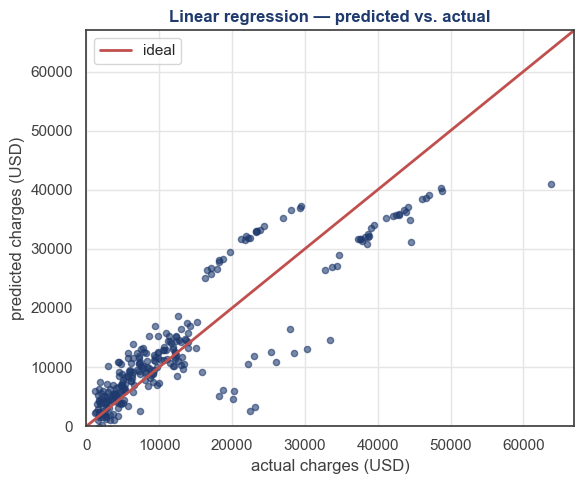

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred_lr, alpha=0.6, s=20, color=PRIMARY)
lim = (0, max(y_test.max(), y_pred_lr.max()) * 1.05)
ax.plot(lim, lim, color=ACCENT_RED, lw=2, label="ideal")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("actual charges (USD)")
ax.set_ylabel("predicted charges (USD)")
ax.set_title("Linear regression — predicted vs. actual")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


**What the scatter tells us.** The points fall into distinct diagonal **bands**. The lower band — mostly non-smokers — hugs the ideal line, so the model predicts those policies well. Above it sit the smokers, whom the model systematically *under-predicts*, and that smoker band itself splits in two along BMI: high-BMI smokers cost dramatically more. That `smoker × bmi` interaction is a non-linearity a plain linear model cannot represent — each feature gets a single fixed coefficient. A decision tree, next, picks it up automatically.

### Model B — Decision tree

A decision tree recursively splits the feature space on the threshold that most reduces within-node variance, then predicts the average target in each leaf. There is no linearity assumption, and non-linear interactions are captured automatically.

In [10]:
from sklearn.tree import DecisionTreeRegressor

# Same pre-processing, but a depth-4 tree instead of a linear model.
tree4_reg = Pipeline([
    ("preprocess", preprocess),
    ("tree", DecisionTreeRegressor(max_depth=4, random_state=SEED)),
])
tree4_reg.fit(X_train, y_train)
y_pred_tree4 = tree4_reg.predict(X_test)

metrics_table(y_test, y_pred_tree4, label="tree (depth 4)")


,RMSE,MAE,R²
tree (depth 4),4592.76,2697.77,0.864


**Reading the metrics.** R² jumps from ≈ 0.78 (linear) to ≈ 0.86 (tree, depth 4) and RMSE drops by about 1.2k USD. The tree picked up the smoker × BMI interaction without being told it existed.

### Tree visualisation — what splits did the tree learn?

The plot below shows the actual decision flow. Each non-leaf node carries the splitting feature and threshold; each leaf shows the predicted charge for policies that land there.


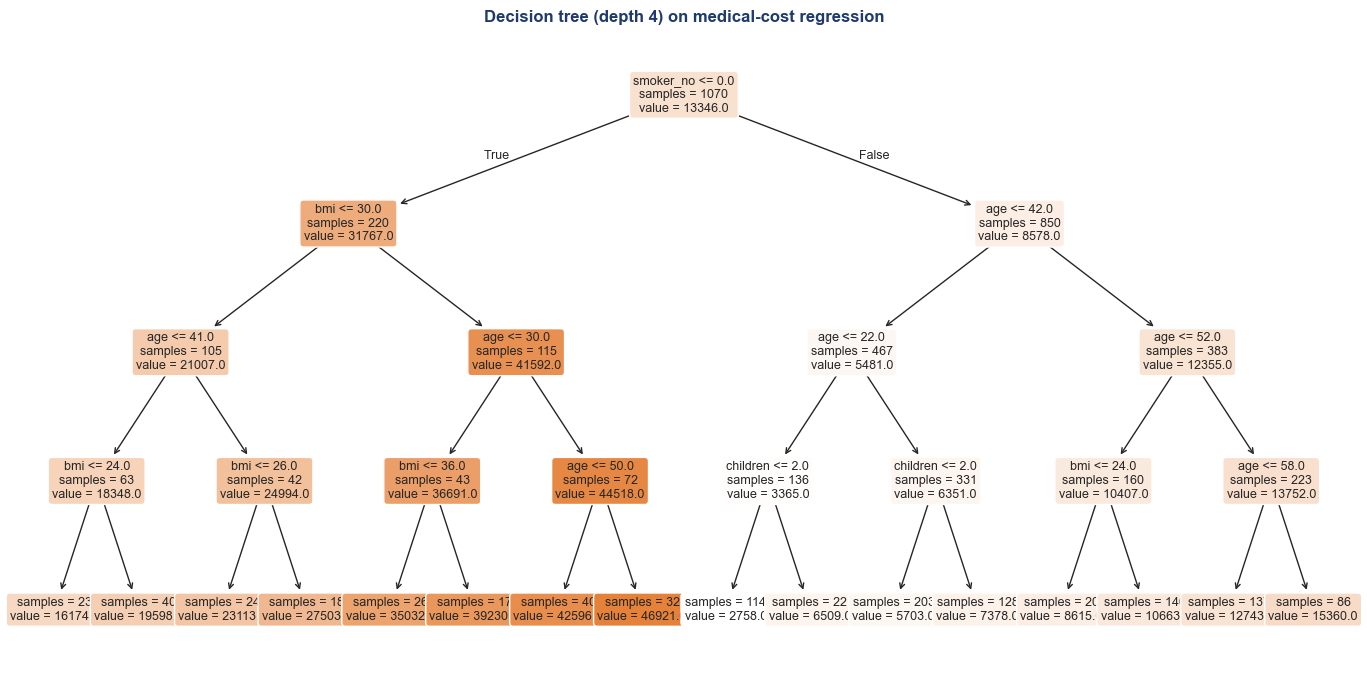

In [11]:
from sklearn.tree import plot_tree

# Draw the fitted tree: each box is a split, each leaf a predicted charge.
fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(
    tree4_reg.named_steps["tree"],
    feature_names=feature_names_reg,
    filled=True,
    rounded=True,
    impurity=False,
    precision=0,
    fontsize=9,
    ax=ax,
)
ax.set_title("Decision tree (depth 4) on medical-cost regression")
fig.tight_layout()
plt.show()


**Reading the tree diagram.** The first split is `smoker_no ≤ 0.0` — i.e. "are you a smoker?" (`smoker_no = 0` means yes-smoker; `smoker_no = 1` means non-smoker). Smokers route left (the highest-charge branches); non-smokers route right. Inside the smoker branch, `bmi` becomes the next dominant split — the smoker-with-high-BMI sub-branch lands at the highest predicted charges. Inside the non-smoker branch, `age` and `bmi` carry the next splits.

This is the *interpretation pay-off* of a decision tree: the model is literally a flow-chart of if-then rules. Read it aloud to an underwriter and they will recognise their own pricing heuristic.


The tree diagram shows *which* splits were chosen; a feature-importance score summarises *how much work each feature does* across the whole tree, measured by the total reduction in variance it is responsible for. Higher means the tree leaned on it more.

In [12]:
# Feature importance = total variance reduction each feature contributed.
importance_table = (
    pd.DataFrame({"importance": tree4_reg.named_steps["tree"].feature_importances_},
                 index=feature_names_reg)
      .sort_values("importance", ascending=False)
)
importance_table.round(3)


,importance
smoker_no,0.703
bmi,0.179
age,0.114
children,0.004
sex_female,0.000
sex_male,0.000
smoker_yes,0.000
region_northeast,0.000
region_northwest,0.000
region_southeast,0.000


**Reading the importances.** The split-importance ranking matches the tree picture: `smoker_no`, `bmi`, `age` do almost all the work; the rest of the features sit near zero. The categorical dummies register essentially zero importance — the tree never used them.


### Bias-variance on real data

Sweep tree depth from 2 to 7; plot training RMSE vs. test RMSE.


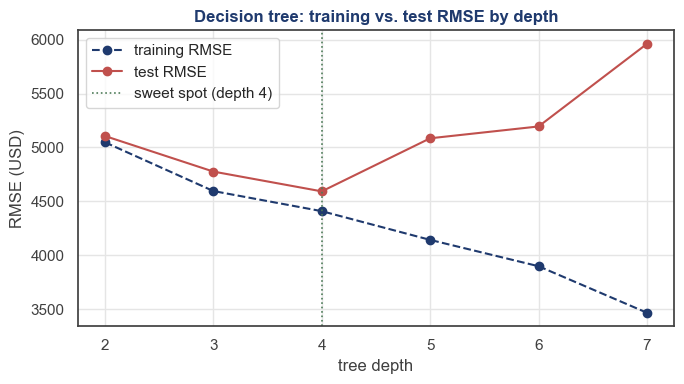

,train_RMSE,test_RMSE
depth,,
2,5048.0,5106.0
3,4596.0,4776.0
4,4409.0,4593.0
5,4143.0,5085.0
6,3899.0,5195.0
7,3467.0,5961.0


In [13]:
# Re-fit the tree across a range of depths, recording train + test RMSE.
depths = [2, 3, 4, 5, 6, 7]
records = []
for d in depths:
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("tree", DecisionTreeRegressor(max_depth=d, random_state=SEED)),
    ])
    pipe.fit(X_train, y_train)
    records.append({
        "depth":      d,
        "train_RMSE": np.sqrt(mean_squared_error(y_train, pipe.predict(X_train))),
        "test_RMSE":  np.sqrt(mean_squared_error(y_test,  pipe.predict(X_test))),
    })
depth_sweep = pd.DataFrame(records).set_index("depth")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depth_sweep.index, depth_sweep["train_RMSE"], "--o",
        color=PRIMARY, label="training RMSE")
ax.plot(depth_sweep.index, depth_sweep["test_RMSE"], "-o",
        color=ACCENT_RED, label="test RMSE")
# The depth with the lowest TEST RMSE is the bias-variance sweet spot.
best = depth_sweep["test_RMSE"].idxmin()
ax.axvline(best, color=ACCENT_GREEN, lw=1.2, ls=":",
           label=f"sweet spot (depth {best})")
ax.set_xlabel("tree depth")
ax.set_ylabel("RMSE (USD)")
ax.set_title("Decision tree: training vs. test RMSE by depth")
ax.legend()
fig.tight_layout()
plt.show()

depth_sweep.round(0)


**Reading the curve.** Training RMSE falls monotonically — a deeper tree always fits the training data better. Test RMSE traces a U: it improves down to depth 4 and then climbs again as the tree starts memorising noise. On this small dataset (~1,070 training rows) the minimum is shallow, at **depth 4**, which is the depth we used above. Where the sweet spot lands is a property of *this* dataset and *this* set of hyperparameters — change the minimum leaf size, the feature set, or the amount of data and it moves; there is no universal "best depth".

### Section comparison


In [14]:
tree_best_reg = Pipeline([
    ("preprocess", preprocess),
    ("tree", DecisionTreeRegressor(max_depth=int(best), random_state=SEED)),
]).fit(X_train, y_train)
y_pred_tree_best = tree_best_reg.predict(X_test)

rows = [
    metrics_table(y_test, y_pred_lr,        "linear regression"),
    metrics_table(y_test, y_pred_tree4,     "tree (depth 4)"),
]
if int(best) != 4:
    rows.append(metrics_table(y_test, y_pred_tree_best, f"tree (depth {int(best)})"))
comparison = pd.concat(rows)
comparison.style.format({"RMSE": "{:,.2f}", "MAE": "{:,.2f}", "R²": "{:.3f}"})


,RMSE,MAE,R²
linear regression,"5,796.28","4,181.19",0.784
tree (depth 4),"4,592.76","2,697.77",0.864


**The verdict on this dataset.** The tree clearly wins on RMSE — its strength is capturing the smoker × BMI interaction without manual feature engineering. R² rises from ≈ 0.78 (linear) to ≈ 0.86 (tree, depth 4), and MAE drops by about a third, from ≈ 4.2k to ≈ 2.7k USD. The linear model still earns its place: every coefficient carries a meaning a doctor or a regulator would understand. In production you would likely **ensemble** several such trees (Section 2) or **engineer** the interaction by hand inside a GLM.

## 2. Binary classification — predicting car-insurance claims

Our second task is a binary classification: predict whether a policyholder will **file a claim** in the next policy year.

> **Dataset.** *Car Insurance Data* on Kaggle ([sagnik1511/car-insurance-data](https://www.kaggle.com/datasets/sagnik1511/car-insurance-data)). 10,000 drivers with 18 columns — age band, gender, driving experience, education, income, credit score, vehicle type, annual mileage, prior speeding violations / DUIs / accidents, a postal-code bucket — and a binary target `OUTCOME` (1 = claim filed, 0 = no claim). Positive rate ≈ 31 %. `CREDIT_SCORE` and `ANNUAL_MILEAGE` have a small fraction (~10 %) of missing values, which we impute inside the modelling pipeline.

Classification is the canonical setting where accuracy is misleading — we will see exactly why.

In [15]:
# Load the car-insurance CSV and drop the ID column (not a feature).
df_cls = pd.read_csv("data/data_car_insurance.csv")
df_cls = df_cls.drop(columns=["ID"])
target = "OUTCOME"

print(f"shape: {df_cls.shape}   positive rate: {df_cls[target].mean():.1%}")
df_cls.head()


shape: (10000, 18)   positive rate: 31.3%


,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


**A quick read.** 10,000 drivers, 17 features after dropping `ID`. The target is `OUTCOME` (claim filed yes/no). Positive rate ≈ 31 % — moderately imbalanced. Features mix demographics (`AGE`, `GENDER`, `RACE`, `EDUCATION`, `INCOME`, `MARRIED`, `CHILDREN`), driving history (`DRIVING_EXPERIENCE`, `SPEEDING_VIOLATIONS`, `DUIS`, `PAST_ACCIDENTS`), credit (`CREDIT_SCORE`), and vehicle attributes (`VEHICLE_OWNERSHIP`, `VEHICLE_YEAR`, `VEHICLE_TYPE`, `ANNUAL_MILEAGE`, `POSTAL_CODE`).


In [16]:
df_cls.describe(include="all").T.head(20)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
AGE,10000,4,26-39,3063,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GENDER,10000,2,female,5010,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RACE,10000,2,majority,9012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DRIVING_EXPERIENCE,10000,4,0-9y,3530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EDUCATION,10000,3,high school,4157,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INCOME,10000,4,upper class,4336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CREDIT_SCORE,9018.0,NaN,NaN,NaN,0.515813,0.137688,0.053358,0.417191,0.525033,0.618312,0.960819
VEHICLE_OWNERSHIP,10000.0,NaN,NaN,NaN,0.697,0.459578,0.0,0.0,1.0,1.0,1.0
VEHICLE_YEAR,10000,2,before 2015,6967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MARRIED,10000.0,NaN,NaN,NaN,0.4982,0.500022,0.0,0.0,0.0,1.0,1.0


**Reading the summary.**

- `AGE` is a four-level categorical (16–25, 26–39, 40–64, 65+).
- `DRIVING_EXPERIENCE` is also a categorical (0–9y, 10–19y, 20–29y, 30y+) — strongly correlated with age but not identical (a 25-year-old with 9y of experience is rare but possible).
- `CREDIT_SCORE` is a 0–1 score with ~10 % missing.
- `ANNUAL_MILEAGE` is in miles, mean ≈ 11,700, ~10 % missing.
- `POSTAL_CODE` looks like a *discrete bucket* (only a handful of unique values) rather than a true free-form postcode — we will treat it as categorical.
- `SPEEDING_VIOLATIONS`, `DUIS`, `PAST_ACCIDENTS` are non-negative counts; most policies have zero.


### Class balance and the accuracy trap

A bar chart of the target plus the claim rate by age band shows where the signal sits.


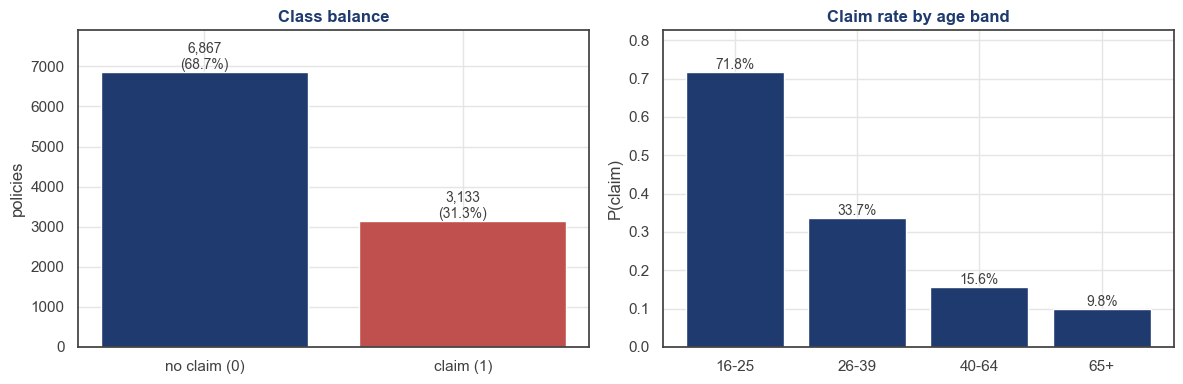

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (1) Class balance — how many policies file a claim at all.
counts = df_cls[target].value_counts().sort_index()
axes[0].bar(["no claim (0)", "claim (1)"], counts.values,
            color=[PRIMARY, ACCENT_RED], edgecolor="white")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}\n({v/len(df_cls):.1%})", ha="center", va="bottom",
                 color=GRAY_TEXT, fontsize=10)
axes[0].set_ylim(0, counts.values.max() * 1.15)
axes[0].set_title("Class balance")
axes[0].set_ylabel("policies")

# (2) Claim rate by age band — where the signal sits.
age_rate = df_cls.groupby("AGE")[target].mean().sort_index()
axes[1].bar(age_rate.index, age_rate.values, color=PRIMARY, edgecolor="white")
for i, v in enumerate(age_rate.values):
    axes[1].text(i, v, f"{v:.1%}", ha="center", va="bottom", color=GRAY_TEXT, fontsize=10)
axes[1].set_title("Claim rate by age band")
axes[1].set_ylabel("P(claim)")
axes[1].set_ylim(0, age_rate.values.max() * 1.15)

fig.tight_layout()
plt.show()


**What the bar charts say.** About 31 % of policies file a claim — the "always predict no" baseline scores about 69 % accuracy without learning anything. The claim rate is *strongly* age-dependent: the youngest band (16–25) sits well above the portfolio average, the oldest band (65+) well below. Any model that ignores `AGE` will leave a lot of signal on the table.


### Stratified train / test split + a metrics helper

Stratify on the target so train and test have the same claim rate. The helper returns log-loss (the natural loss for probability outputs), AUC (ranking quality, threshold-free), F1, and accuracy.


> **Note.** To turn probabilities into yes/no labels for the confusion matrix, F1, and accuracy we threshold at 0.5. With a ~31 % claim rate that default is reasonable, but the cut-off is really a business choice — lowering it catches more claims at the cost of more false alarms. Techniques for strongly imbalanced targets (resampling, class weights, threshold tuning) are covered in Section 4.

In [18]:
from sklearn.metrics import log_loss, roc_auc_score, f1_score, accuracy_score
from sklearn.impute import SimpleImputer

X_cls = df_cls.drop(columns=[target])
y_cls = df_cls[target].astype(int)

# Stratify so train and test carry the same ~31 % claim rate.
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.20, random_state=SEED, stratify=y_cls
)

# All numeric columns include some 0/1 booleans (VEHICLE_OWNERSHIP, MARRIED,
# CHILDREN), which we leave as numeric. POSTAL_CODE is a discrete bucket — we
# treat it as categorical because its scale is meaningless.
num_cols_cls = [c for c in X_train_c.columns
                if X_train_c[c].dtype != "object" and c != "POSTAL_CODE"]
cat_cols_cls = [c for c in X_train_c.columns if c not in num_cols_cls]

print("numeric  :", num_cols_cls)
print("categorical:", cat_cols_cls)
print(f"train claim rate: {y_train_c.mean():.3f}   test claim rate: {y_test_c.mean():.3f}")


numeric  : ['CREDIT_SCORE', 'VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN', 'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS']
categorical: ['AGE', 'GENDER', 'RACE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME', 'VEHICLE_YEAR', 'POSTAL_CODE', 'VEHICLE_TYPE']
train claim rate: 0.313   test claim rate: 0.314


### Model A — Logistic regression

Logistic regression passes the linear combination of features through the sigmoid to produce a probability, and is fit by minimising log-loss (binary cross-entropy):

$$P(Y=1 \mid x) = \sigma(\beta_0 + \beta_1 x_1 + \dots + \beta_p x_p), \qquad \sigma(z) = \frac{1}{1 + e^{-z}}.$$

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Numeric columns: impute the median, then standardise.
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])
# Categorical columns: impute the mode, then one-hot encode.
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocess_cls = ColumnTransformer([
    ("num", numeric_pipe,     num_cols_cls),
    ("cat", categorical_pipe, cat_cols_cls),
])

# Fit logistic regression and read out held-out claim probabilities.
logreg = Pipeline([("preprocess", preprocess_cls),
                   ("logreg",     LogisticRegression(max_iter=1000))]).fit(X_train_c, y_train_c)
p_pred_lr = logreg.predict_proba(X_test_c)[:, 1]

def class_metrics(y_true, y_proba, label="model"):
    y_pred = (y_proba >= 0.5).astype(int)
    return pd.DataFrame({
        "log_loss": [log_loss(y_true, y_proba)],
        "AUC":      [roc_auc_score(y_true, y_proba)],
        "F1":       [f1_score(y_true, y_pred)],
        "accuracy": [accuracy_score(y_true, y_pred)],
    }, index=[label])

class_metrics(y_test_c, p_pred_lr, "logistic regression").round(4)


,log_loss,AUC,F1,accuracy
logistic regression,0.341,0.9155,0.755,0.8475


**Reading the metrics.** Accuracy in the mid-80s is well above the trivial baseline of 69 %. AUC near 0.92 is excellent — the model orders policies well. Log-loss around 0.34 is the headline number for downstream probability use (pricing, retention). F1 around 0.76 says the model is a usable detector at the default 0.5 threshold.


In [20]:
feature_names_cls = (
    num_cols_cls
    + list(logreg.named_steps["preprocess"]
                 .named_transformers_["cat"]
                 .named_steps["onehot"]
                 .get_feature_names_out(cat_cols_cls))
)
coef_table = (
    pd.DataFrame({
        "coef (log-odds)": logreg.named_steps["logreg"].coef_[0],
        "odds-ratio":      np.exp(logreg.named_steps["logreg"].coef_[0]),
    }, index=feature_names_cls)
      .sort_values("coef (log-odds)", key=np.abs, ascending=False)
)
coef_table.head(10).round(3)


,coef (log-odds),odds-ratio
POSTAL_CODE_21217,5.022,151.657
DRIVING_EXPERIENCE_0-9y,2.624,13.785
POSTAL_CODE_10238,-2.596,0.075
DRIVING_EXPERIENCE_30y+,-1.957,0.141
DRIVING_EXPERIENCE_20-29y,-1.482,0.227
POSTAL_CODE_32765,-1.370,0.254
POSTAL_CODE_92101,-1.220,0.295
VEHICLE_YEAR_after 2015,-1.049,0.350
VEHICLE_YEAR_before 2015,0.886,2.425
VEHICLE_OWNERSHIP,-0.860,0.423


**What the top coefficients say.** Read on the log-odds scale, the strongest signals are these.

- **Driving experience** carries the genuine risk signal: `DRIVING_EXPERIENCE_0-9y` pushes the claim odds sharply **up**, while the `20-29y` and `30y+` bands push them **down** — exactly the pattern any motor actuary expects. `AGE` barely appears, because it is almost collinear with driving experience and the model loads the shared signal onto experience.
- `VEHICLE_OWNERSHIP` is negative (owners file fewer claims than leasers) and `VEHICLE_YEAR_after 2015` is negative (newer cars, fewer claims).
- One coefficient looks alarming: `POSTAL_CODE_21217` shows an odds-ratio around 150. That is **not** a real risk effect — it is an artefact of *quasi-complete separation*. Only ~120 of the 10,000 policies sit in that bucket and **every one of them filed a claim**, so the optimiser drives the coefficient as high as it can. It is a textbook reminder to watch for tiny, perfectly-separated categories; in production you would merge rare buckets or add regularisation. We leave it in here as a teaching example.

The numeric features were standardised before fitting, so their magnitudes are broadly comparable; the one-hot dummies (postal-code and experience bands) are 0/1 indicators, so compare those to each other rather than to the scaled numerics.

### Model B — Decision tree

Same recipe but the classifier minimises Gini impurity instead of variance.


In [21]:
from sklearn.tree import DecisionTreeClassifier

tree4_cls = Pipeline([
    ("preprocess", preprocess_cls),
    ("tree",       DecisionTreeClassifier(max_depth=4, random_state=SEED)),
]).fit(X_train_c, y_train_c)
p_pred_tree4 = tree4_cls.predict_proba(X_test_c)[:, 1]

class_metrics(y_test_c, p_pred_tree4, "tree (depth 4)").round(4)


,log_loss,AUC,F1,accuracy
tree (depth 4),0.3824,0.8855,0.7259,0.8305


**Reading the metrics.** The depth-4 tree lands a little *behind* the logistic baseline on every metric — slightly higher log-loss and slightly lower AUC, F1, and accuracy. That is fine and honest: a single shallow tree is a weak standalone learner here. And as we push the depth, the one number that matters most for probabilities — log-loss — gets *worse*, not better, as we see next.

### Tree visualisation — what does the classifier split on?


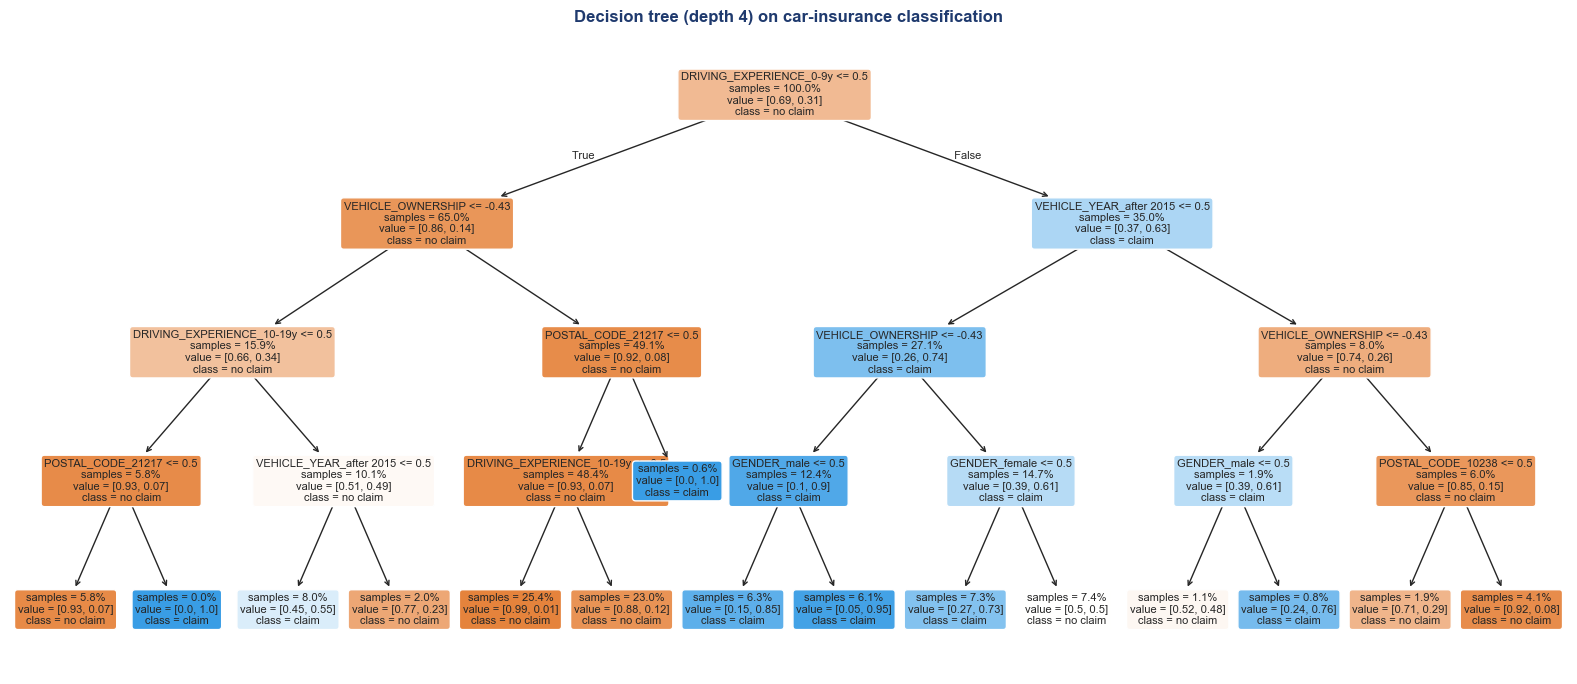

In [22]:
# Plot the fitted classifier; leaves are coloured by predicted class.
fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(
    tree4_cls.named_steps["tree"],
    feature_names=feature_names_cls,
    class_names=["no claim", "claim"],
    filled=True,
    rounded=True,
    impurity=False,
    proportion=True,
    precision=2,
    fontsize=8,
    ax=ax,
)
ax.set_title("Decision tree (depth 4) on car-insurance classification")
fig.tight_layout()
plt.show()


**Reading the tree.** The root split is `DRIVING_EXPERIENCE_0-9y` — "is this a low-experience driver?". Low-experience drivers branch right into the higher-claim leaves (predicted claim probabilities above 0.6); more-experienced drivers branch left into the lower-claim leaves. From there the experienced branch splits next on `VEHICLE_OWNERSHIP`, and the low-experience branch on `VEHICLE_YEAR`; deeper splits use the `POSTAL_CODE` buckets, `GENDER`, and the finer `DRIVING_EXPERIENCE` bands. With `proportion=True`, each leaf shows the share of training policies that reached it and the predicted class probabilities.

This is the actuarial pay-off: a depth-4 tree is literally a flow-chart an underwriter could read off a clipboard. In a moment we will see why going *deeper* is the wrong move for a probability task.

### Bias-variance for a probability task — log-loss, not accuracy

As tree depth grows, training log-loss collapses toward zero, but test log-loss climbs sharply: a deep tree's leaves predict near-0 or near-1 with full confidence, and a single wrongly-confident prediction blows up log-loss.


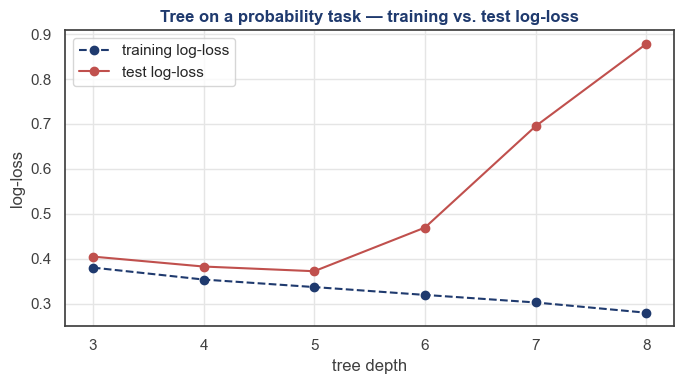

,train_log_loss,test_log_loss
depth,,
3,0.380,0.405
4,0.353,0.382
5,0.337,0.372
6,0.319,0.469
7,0.302,0.695
8,0.279,0.878


In [23]:
# Sweep depth and track train vs. test log-loss (not accuracy).
depths = [3, 4, 5, 6, 7, 8]
records = []
for d in depths:
    pipe = Pipeline([
        ("preprocess", preprocess_cls),
        ("tree",       DecisionTreeClassifier(max_depth=d, random_state=SEED)),
    ])
    pipe.fit(X_train_c, y_train_c)
    eps = 1e-15
    p_tr = np.clip(pipe.predict_proba(X_train_c)[:, 1], eps, 1 - eps)
    p_te = np.clip(pipe.predict_proba(X_test_c )[:, 1], eps, 1 - eps)
    records.append({
        "depth":          d,
        "train_log_loss": log_loss(y_train_c, p_tr),
        "test_log_loss":  log_loss(y_test_c,  p_te),
    })
depth_sweep_cls = pd.DataFrame(records).set_index("depth")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depth_sweep_cls.index, depth_sweep_cls["train_log_loss"], "--o",
        color=PRIMARY, label="training log-loss")
ax.plot(depth_sweep_cls.index, depth_sweep_cls["test_log_loss"], "-o",
        color=ACCENT_RED, label="test log-loss")
ax.set_xlabel("tree depth")
ax.set_ylabel("log-loss")
ax.set_title("Tree on a probability task — training vs. test log-loss")
ax.legend()
fig.tight_layout()
plt.show()

depth_sweep_cls.round(3)


**Reading the curve.** Training log-loss heads toward 0 as the tree memorises the labels; test log-loss climbs once the leaves get small enough to over-fit noise. This is harsher than the regression bias-variance story — for probability tasks, a single deep tree is *especially* bad.


### Diagnostics: confusion matrix, ROC, calibration

Three plots side-by-side decide whether a probabilistic model is fit for purpose. The calibration plot is where logistic regression and trees go separate ways.


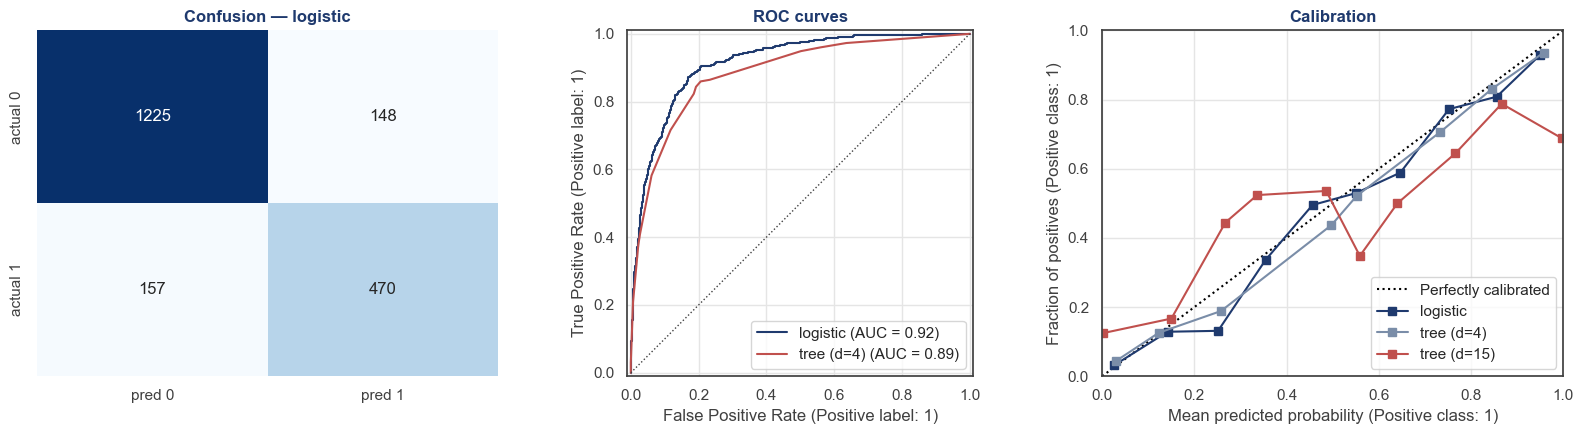

In [24]:
from sklearn.metrics import confusion_matrix, RocCurveDisplay
from sklearn.calibration import CalibrationDisplay

# A deliberately deep (overfit) tree to expose the calibration problem.
tree_deep = Pipeline([
    ("preprocess", preprocess_cls),
    ("tree",       DecisionTreeClassifier(max_depth=15, random_state=SEED)),
]).fit(X_train_c, y_train_c)
p_pred_tree_deep = tree_deep.predict_proba(X_test_c)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

cm_lr = confusion_matrix(y_test_c, (p_pred_lr >= 0.5).astype(int))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["pred 0", "pred 1"], yticklabels=["actual 0", "actual 1"])
axes[0].set_title("Confusion — logistic")

RocCurveDisplay.from_predictions(y_test_c, p_pred_lr,    name="logistic",
                                  ax=axes[1], color=PRIMARY)
RocCurveDisplay.from_predictions(y_test_c, p_pred_tree4, name="tree (d=4)",
                                  ax=axes[1], color=ACCENT_RED)
axes[1].plot([0, 1], [0, 1], color=GRAY_TEXT, ls=":", lw=1)
axes[1].set_title("ROC curves")

CalibrationDisplay.from_predictions(y_test_c, p_pred_lr,         n_bins=10,
                                    name="logistic",    ax=axes[2], color=PRIMARY)
CalibrationDisplay.from_predictions(y_test_c, p_pred_tree4,      n_bins=10,
                                    name="tree (d=4)",  ax=axes[2], color="#7A8DA8")
CalibrationDisplay.from_predictions(y_test_c, p_pred_tree_deep,  n_bins=10,
                                    name="tree (d=15)", ax=axes[2], color=ACCENT_RED)
axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1)
axes[2].set_title("Calibration")

fig.tight_layout()
plt.show()


**Reading the diagnostics.**

- *Confusion matrix.* The logistic model catches most no-claims (large true negatives) and most claims (the bottom-right cell is healthy). Misses are roughly balanced between false positives and false negatives.
- *ROC curves.* Both curves bow well above the diagonal — both models discriminate well. The logistic curve sits just above the tree's across most operating points.
- *Calibration plot — the felt-difference moment.* The **logistic** curve hugs the diagonal: when it says "30 % probability", roughly 30 % of those policies really do file a claim. The **shallow tree** emits only a handful of distinct probabilities, so its curve has visible "steps". The **deep tree** zigzags off the diagonal — its leaves emit confident 0 or 1 outputs that are wrong on a meaningful share of held-out policies.

A deep tree may still rank policies well (good AUC) but its probabilities cannot be plugged into a pricing formula. **For probability tasks a single tree is the wrong tool** — Section 2 fixes this with ensembles.


### Section comparison


In [25]:
best_d = int(depth_sweep_cls["test_log_loss"].idxmin())
rows = [
    class_metrics(y_test_c, p_pred_lr,    "logistic regression"),
    class_metrics(y_test_c, p_pred_tree4, "tree (depth 4)"),
]
if best_d != 4:
    tree_best_cls = Pipeline([
        ("preprocess", preprocess_cls),
        ("tree",       DecisionTreeClassifier(max_depth=best_d, random_state=SEED)),
    ]).fit(X_train_c, y_train_c)
    p_pred_tree_best = tree_best_cls.predict_proba(X_test_c)[:, 1]
    rows.append(class_metrics(y_test_c, p_pred_tree_best, f"tree (depth {best_d})"))
comparison_cls = pd.concat(rows)
comparison_cls.style.format({"log_loss": "{:.4f}", "AUC": "{:.3f}", "F1": "{:.3f}", "accuracy": "{:.3f}"})


,log_loss,AUC,F1,accuracy
logistic regression,0.3410,0.915,0.755,0.848
tree (depth 4),0.3824,0.886,0.726,0.831
tree (depth 5),0.3720,0.895,0.725,0.839


**The verdict.** Logistic regression beats the single tree on **every** metric here — log-loss, AUC, F1, and accuracy alike — so there is no accuracy-versus-calibration trade-off to agonise over on this dataset: the logistic model is the better classifier *and* the better-calibrated one. The calibration plot drives the point home — only the logistic probabilities are believable. Whenever the downstream decision needs a probability (pricing, reserving, retention spend), reach for the logistic model, or for an ensemble that restores calibration (Section 2).

## 3. Clustering — segmenting a car-insurance portfolio

For the last section we forget the target. Imagine the same car-insurance portfolio but with no `OUTCOME` column — no labels at all. Can we still find structure that turns into actionable actuarial narratives? That is the job of k-means: partition the drivers into K groups so that each driver sits closest to its group's centre.

In [26]:
df_unsup = df_cls.drop(columns=[target])
df_unsup.head()


,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS
0,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0
1,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0
2,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0
3,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0
4,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1


### Standardise features and impute missings

K-means measures Euclidean distance, so features must be on comparable scales. We impute the small fraction of missing values and standardise the numeric columns. POSTAL_CODE is treated as categorical for the same reason it was in the classifier.


In [27]:
# Split columns into numeric vs categorical (POSTAL_CODE is a bucket id).
cat_cols_u = [c for c in df_unsup.columns if df_unsup[c].dtype == "object" or c == "POSTAL_CODE"]
num_cols_u = [c for c in df_unsup.columns if c not in cat_cols_u]

preprocess_unsup = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale",  StandardScaler())]),               num_cols_u),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols_u),
])
X_scaled = preprocess_unsup.fit_transform(df_unsup)
print(f"scaled feature matrix: {X_scaled.shape}")


scaled feature matrix: (10000, 35)


### Choosing K — elbow and silhouette

K-means looks for the cluster assignment and centroids $\mu_k$ that minimise the within-cluster sum of squares:

$$\sum_{k=1}^{K}\ \sum_{x_i \in C_k} \lVert x_i - \mu_k \rVert^2.$$

This inertia falls monotonically as K grows, so we look for the *elbow* where the gain flattens. The silhouette score complements it with a measure of how cleanly the clusters separate.

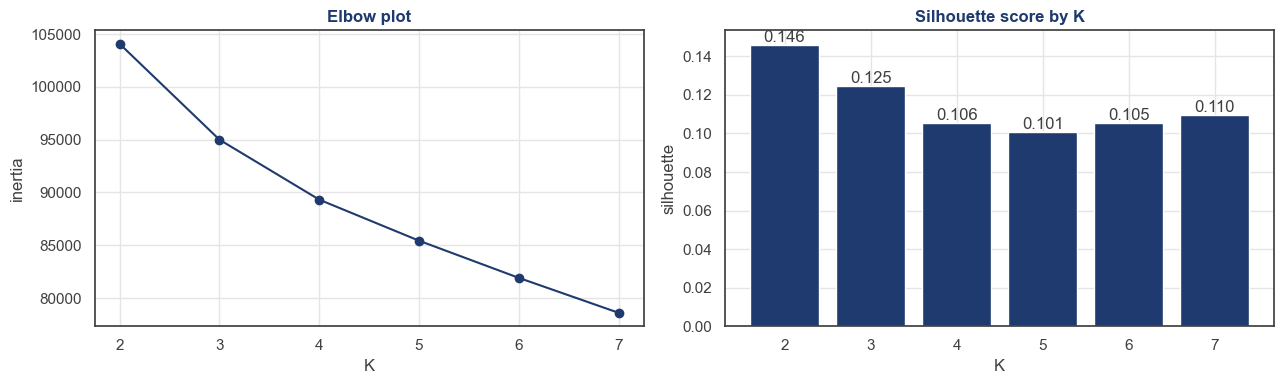

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Ks = list(range(2, 8))
inertias = []
sil_scores = []

rng = np.random.default_rng(SEED)
sample_idx = rng.choice(X_scaled.shape[0], size=4_000, replace=False)
X_sample = X_scaled[sample_idx]

# Fit k-means for each K, recording inertia and a sampled silhouette.
for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, km.predict(X_sample)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(Ks, inertias, "-o", color=PRIMARY)
axes[0].set_xlabel("K"); axes[0].set_ylabel("inertia")
axes[0].set_title("Elbow plot")

axes[1].bar([str(k) for k in Ks], sil_scores, color=PRIMARY, edgecolor="white")
for i, v in enumerate(sil_scores):
    axes[1].text(i, v, f"{v:.3f}", ha="center", va="bottom", color=GRAY_TEXT)
axes[1].set_xlabel("K"); axes[1].set_ylabel("silhouette")
axes[1].set_title("Silhouette score by K")

fig.tight_layout()
plt.show()


**Reading the plots.** Inertia bends most around K = 3 and then flattens, and the silhouette is higher at K = 3 (≈ 0.125) than at K = 4 (≈ 0.106) — both point to **K = 3**. Real-portfolio silhouettes are modest across the board (insurance data rarely separates into crisp balls), so we lean on the elbow and on interpretability. K = 3 also gives the cleanest actuarial story — three segments that do not overlap — whereas K = 4 mostly splits the young-driver group into two near-duplicates. We commit to K = 3.

In [29]:
# Commit to three clusters (see the discussion above) and fit on all rows.
K_CHOICE = 3
kmeans = KMeans(n_clusters=K_CHOICE, n_init=10, random_state=SEED).fit(X_scaled)
labels = kmeans.labels_
pd.Series(labels, name="cluster").value_counts().sort_index()


cluster
0    3776
1    4302
2    1922
Name: count, dtype: int64

Three clusters of clearly different sizes — a large young-driver group, a large mature-driver group, and a smaller senior group — with none degenerate.

### A 2D projection of the clusters

Project the scaled features into two principal components purely for visualisation. The clustering itself happened in the full feature space.


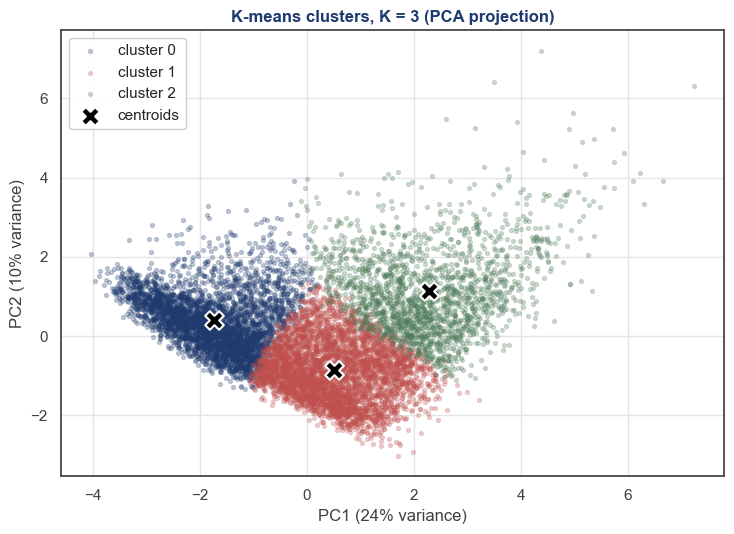

In [30]:
from sklearn.decomposition import PCA

# Project to 2D for plotting only; clustering used the full feature space.
pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X_scaled)
centroids_2d = pca.transform(kmeans.cluster_centers_)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
palette = [PRIMARY, ACCENT_RED, ACCENT_GREEN, "#7A8DA8"]
for k in range(K_CHOICE):
    mask = labels == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=8, alpha=0.25,
               color=palette[k], label=f"cluster {k}")
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1], s=180, marker="X",
           color="black", edgecolor="white", linewidth=1.5, label="centroids")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)")
ax.set_title(f"K-means clusters, K = {K_CHOICE} (PCA projection)")
ax.legend(loc="best", framealpha=0.95)
fig.tight_layout()
plt.show()


**What the projection shows.** The three clusters line up mostly along PC1, which on this portfolio is dominated by the age / driving-experience / credit-score axis — the algorithm found structure aligned with the strongest signal in the data. PC1 and PC2 together explain only part of the total variance, so the clean separation you see here understates the overlap that still exists in the full feature space.

### Reading the centroids — back-transform to original units


In [31]:
num_scaler = preprocess_unsup.named_transformers_["num"].named_steps["scale"]
num_imputer = preprocess_unsup.named_transformers_["num"].named_steps["impute"]

# Inverse-transform the numeric part of the centroids
# Undo the scaling so centroid numbers are in original, readable units.
centroid_num = pd.DataFrame(
    num_scaler.inverse_transform(kmeans.cluster_centers_[:, :len(num_cols_u)]),
    columns=num_cols_u,
)

# Categorical part: mode per cluster on the original DataFrame
centroid_cat = pd.DataFrame({
    col: [df_unsup.loc[labels == k, col].mode().iloc[0] for k in range(K_CHOICE)]
    for col in cat_cols_u
})

# Also attach the observed claim rate per cluster (using the held-out label
# only for narrative — the clustering itself never saw it).
claim_rate = df_cls.assign(cluster=labels).groupby("cluster")[target].mean().round(3)
centroids = pd.concat([centroid_num.round(2), centroid_cat, claim_rate.rename("obs_claim_rate")], axis=1)
centroids.index.name = "cluster"
centroids


,CREDIT_SCORE,VEHICLE_OWNERSHIP,MARRIED,CHILDREN,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,VEHICLE_YEAR,POSTAL_CODE,VEHICLE_TYPE,obs_claim_rate
cluster,,,,,,,,,,,,,,,,,,
0,0.42,0.46,0.12,0.37,13360.70,0.44,0.08,0.35,16-25,female,majority,0-9y,high school,poverty,before 2015,10238,sedan,0.581
1,0.58,0.85,0.72,0.87,10970.00,1.03,0.10,0.72,40-64,female,majority,10-19y,university,upper class,before 2015,10238,sedan,0.191
2,0.57,0.82,0.74,0.90,10207.38,4.54,0.87,3.20,65+,male,majority,20-29y,university,upper class,before 2015,10238,sedan,0.061


**Turning centroids into actuarial narratives.** With K = 3 the table reads as three clean portfolio segments:

- **Cluster — young, high-risk (size ≈ 3,800).** 16–25, under 10 years' experience, lower income, lowest credit score, and frequently *not* the vehicle owner. Observed claim rate ≈ **58 %** — nearly double the 31 % portfolio average.
- **Cluster — mature mainstream (size ≈ 4,300).** 40–64, 10–19 years' experience, higher income, vehicle owners. Observed claim rate ≈ **19 %** — the dependable core of the book.
- **Cluster — seniors (size ≈ 1,900).** 65+, 20–29 years' experience, the **lowest** observed claim rate (≈ **6 %**) despite carrying the most prior speeding violations, DUIs, and past accidents — a reminder that a long *history* of incidents is not the same as a high *current* claim propensity.

The `obs_claim_rate` column is the sanity check: even though k-means never saw `OUTCOME`, the three clusters spread the claim rate from ≈ 6 % to ≈ 58 % — almost a ten-fold range. That is the unsupervised payoff: a genuinely useful portfolio segmentation produced *without* labels.

## Exercises

Five short hands-on exercises to deepen your intuition. Each ships a self-contained **starter** cell and a worked **solution** cell — run them yourself to see the output, then modify and explore. The discussion in the room expands on each one.

### Exercise 1 — Push the regression tree harder

Re-fit the medical-cost decision tree with `max_depth=10` and compare the test metrics against the depth-4 baseline. What happened to test RMSE? What happened to *training* RMSE? Use this contrast to argue for the depth-4 sweet spot.


In [32]:
# Exercise 1 starter — depth-10 regression tree on medical cost
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

tree_deep = Pipeline([
    ("preprocess", preprocess),
    ("tree", DecisionTreeRegressor(max_depth=10, random_state=SEED)),
]).fit(X_train, y_train)
y_pred_train = tree_deep.predict(X_train)
y_pred_test  = tree_deep.predict(X_test)

print(f"depth-10 — train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):,.0f}")
print(f"depth-10 —  test RMSE: {np.sqrt(mean_squared_error(y_test,  y_pred_test)):,.0f}")

# For comparison, the depth-4 baseline:
print(f"depth-4  —  test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_tree4)):,.0f}")

# Your turn: is depth 10 better? Worse? Why?


depth-10 — train RMSE: 2,060
depth-10 —  test RMSE: 5,991
depth-4  —  test RMSE: 4,593


In [33]:
# Solution — depth-10 overfits; depth-4 is the bias–variance sweet spot
# Training RMSE drops sharply but test RMSE *worsens* at depth 10 — the deeper
# tree memorises noise instead of capturing the true signal.
rmse_train_d10 = np.sqrt(mean_squared_error(y_train, tree_deep.predict(X_train)))
rmse_test_d10  = np.sqrt(mean_squared_error(y_test,  tree_deep.predict(X_test)))
rmse_test_d4   = np.sqrt(mean_squared_error(y_test,  y_pred_tree4))
print(f"depth-10 generalisation gap (test − train RMSE): {rmse_test_d10 - rmse_train_d10:,.0f}")
print(f"depth-10 vs depth-4 test RMSE: {rmse_test_d10:,.0f} vs {rmse_test_d4:,.0f}")
print("Verdict: depth-4 wins on test. The deeper tree fits noise the shallower one ignores.")

depth-10 generalisation gap (test − train RMSE): 3,930
depth-10 vs depth-4 test RMSE: 5,991 vs 4,593
Verdict: depth-4 wins on test. The deeper tree fits noise the shallower one ignores.


### Exercise 2 — Seed sensitivity

The random seed enters every model we fit (train/test split, tree construction, k-means initialisation). Pick three seeds (e.g. 0, 7, 42) and re-fit the **classification tree** on the car-insurance dataset. How much does the test log-loss wobble? A rule of thumb: if your "improvement" between two models is smaller than the seed-to-seed variability, you have not improved anything.


In [34]:
# Exercise 2 starter — seed sensitivity on the car-insurance classification tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import log_loss

results = []
for s in (0, 7, 42):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_cls, y_cls, test_size=0.20, random_state=s, stratify=y_cls
    )
    tree_s = Pipeline([
        ("preprocess", preprocess_cls),
        ("tree",       DecisionTreeClassifier(max_depth=4, random_state=s)),
    ]).fit(X_tr, y_tr)
    p = tree_s.predict_proba(X_te)[:, 1]
    results.append({"seed": s, "test_log_loss": log_loss(y_te, p)})

pd.DataFrame(results).round(4)


,seed,test_log_loss
0,0,0.3490
1,7,0.3667
2,42,0.3824


In [35]:
# Solution — quantify the seed-to-seed wobble
# Rule of thumb: a competing model that "improves" log-loss by less than this
# spread has improved nothing — the change is inside seed noise.
ll = [r["test_log_loss"] for r in results]
print(f"Seed-to-seed std of test log-loss: {np.std(ll):.4f}")
print(f"Range across seeds (0, 7, 42):      [{min(ll):.4f}, {max(ll):.4f}]")

Seed-to-seed std of test log-loss: 0.0137
Range across seeds (0, 7, 42):      [0.3490, 0.3824]


### Exercise 3 — Swap dataset: predict CREDIT_SCORE on the car-insurance portfolio

The car-insurance dataset has a numeric `CREDIT_SCORE` column. Treat that as a *regression* target (instead of `OUTCOME`). Re-fit a linear regression and a depth-4 decision tree. Which one wins?

The cell below copies the regression workflow from §1, just pointing at a different dataset and target.


In [36]:
# Exercise 3 starter — regression on car-insurance, predicting CREDIT_SCORE
df_ex = pd.read_csv("data/data_car_insurance.csv").drop(columns=["ID"])
df_ex = df_ex.dropna(subset=["CREDIT_SCORE"])           # use complete rows only
target_ex = "CREDIT_SCORE"
X_ex = df_ex.drop(columns=[target_ex, "OUTCOME"])       # exclude the original target
y_ex = df_ex[target_ex]

X_tr_e, X_te_e, y_tr_e, y_te_e = train_test_split(
    X_ex, y_ex, test_size=0.20, random_state=SEED
)

num_e = [c for c in X_tr_e.columns
         if X_tr_e[c].dtype != "object" and c != "POSTAL_CODE"]
cat_e = [c for c in X_tr_e.columns if c not in num_e]

preprocess_ex = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale",  StandardScaler())]),               num_e),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_e),
])

lin_ex  = Pipeline([("p", preprocess_ex), ("m", LinearRegression())]).fit(X_tr_e, y_tr_e)
tree_ex = Pipeline([("p", preprocess_ex), ("m", DecisionTreeRegressor(max_depth=4, random_state=SEED))]).fit(X_tr_e, y_tr_e)

pd.concat([
    metrics_table(y_te_e, lin_ex.predict(X_te_e),  "linear on CREDIT_SCORE"),
    metrics_table(y_te_e, tree_ex.predict(X_te_e), "tree  on CREDIT_SCORE"),
]).round(3)


,RMSE,MAE,R²
linear on CREDIT_SCORE,0.09,0.07,0.568
tree on CREDIT_SCORE,0.09,0.07,0.569


In [37]:
# Solution — which model wins on CREDIT_SCORE?
# CREDIT_SCORE on this portfolio is dominated by a handful of categorical signals
# (vehicle type, income bracket, postal code) where a tree carves sharper splits
# than a linear model. Tree typically wins on test RMSE — but verify on your seed.
rmse_lin  = np.sqrt(mean_squared_error(y_te_e, lin_ex.predict(X_te_e)))
rmse_tree = np.sqrt(mean_squared_error(y_te_e, tree_ex.predict(X_te_e)))
print(f"Linear test RMSE: {rmse_lin:,.3f}")
print(f"Tree   test RMSE: {rmse_tree:,.3f}")
print(f"Winner: {'tree' if rmse_tree < rmse_lin else 'linear'}.")

Linear test RMSE: 0.092
Tree   test RMSE: 0.092
Winner: tree.


### Exercise 4 — Hyperparameter tuning with `GridSearchCV`

We picked `max_depth=4` by eyeballing the bias-variance curve. A more disciplined approach is a *grid search* with cross-validation. Sweep three hyperparameters of the classification tree on the car-insurance task: `max_depth ∈ {3, 4, 5, 6}`, `min_samples_leaf ∈ {2, 5, 10, 20}`, `criterion ∈ {"gini", "entropy"}`. Report the winning combination and its CV log-loss.

> **Note.** A grid this small (32 combinations × 3-fold CV ≈ 100 fits) is cheap to run. On larger grids look into `RandomizedSearchCV` or `HalvingGridSearchCV`.


In [38]:
# Exercise 4 starter — GridSearchCV on the classification tree
from sklearn.model_selection import GridSearchCV

param_grid = {
    "tree__max_depth":        [3, 4, 5, 6],
    "tree__min_samples_leaf": [2, 5, 10, 20],
    "tree__criterion":        ["gini", "entropy"],
}

base_pipe = Pipeline([
    ("preprocess", preprocess_cls),
    ("tree",       DecisionTreeClassifier(random_state=SEED)),
])

search = GridSearchCV(
    base_pipe,
    param_grid,
    scoring="neg_log_loss",
    cv=3,
    n_jobs=-1,
    refit=True,
)
search.fit(X_train_c, y_train_c)

print("Best params:", search.best_params_)
print(f"Best CV log-loss: {-search.best_score_:.4f}")

# Score the refit best estimator on the held-out test set
p_best = search.predict_proba(X_test_c)[:, 1]
class_metrics(y_test_c, p_best, "GridSearchCV best tree").round(4)


Best params: {'tree__criterion': 'gini', 'tree__max_depth': 5, 'tree__min_samples_leaf': 20}
Best CV log-loss: 0.3512


,log_loss,AUC,F1,accuracy
GridSearchCV best tree,0.3735,0.8955,0.7277,0.8395


In [39]:
# Solution — read off the winner and verify on held-out test
from sklearn.metrics import log_loss
print("Best hyperparameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV log-loss:           {-search.best_score_:.4f}")
print(f"Refit-best test log-loss:   {log_loss(y_test_c, search.predict_proba(X_test_c)[:, 1]):.4f}")
# Typical finding on this data: shallow tree (depth 3–5) with min_samples_leaf >= 20
# beats the default unconstrained tree. The criterion choice is essentially noise.

Best hyperparameters:
  tree__criterion: gini
  tree__max_depth: 5
  tree__min_samples_leaf: 20

Best CV log-loss:           0.3512
Refit-best test log-loss:   0.3735


### Exercise 5 — Cluster the medical-cost portfolio

We clustered the car-insurance portfolio. Try the same recipe on the medical-cost dataset (1,338 individuals, 6 features). Choose `K` by elbow/silhouette and interpret the centroids — which segment of the population shows up at the highest predicted `charges`?

> **Hint.** With only six features and 1,338 rows, expect the dominant split to be smoker / non-smoker, with `age` and `bmi` carving the secondary structure.


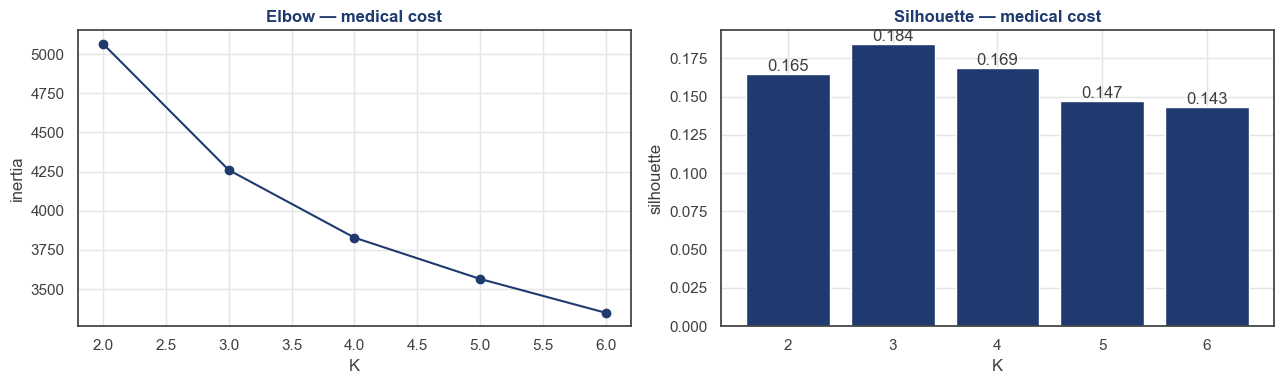

In [40]:
# Exercise 5 starter — k-means on the medical-cost portfolio
df_med = pd.read_csv("data/data_medical_cost.csv")
target_med = "charges"
X_med = df_med.drop(columns=[target_med])

cat_med = ["sex", "smoker", "region"]
num_med = ["age", "bmi", "children"]

# Standardise numerics + one-hot the categoricals (k-means needs comparable scales).
preprocess_med = ColumnTransformer([
    ("num", StandardScaler(),                       num_med),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_med),
])
X_med_scaled = preprocess_med.fit_transform(X_med)

# Sweep K and plot inertia (elbow) + silhouette, just like Section 3.
from sklearn.metrics import silhouette_score
Ks_ex = list(range(2, 7))
inertias_ex, sils_ex = [], []
for k in Ks_ex:
    km_ex = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_med_scaled)
    inertias_ex.append(km_ex.inertia_)
    sils_ex.append(silhouette_score(X_med_scaled, km_ex.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(Ks_ex, inertias_ex, "-o", color=PRIMARY)
axes[0].set_xlabel("K"); axes[0].set_ylabel("inertia"); axes[0].set_title("Elbow — medical cost")
axes[1].bar([str(k) for k in Ks_ex], sils_ex, color=PRIMARY, edgecolor="white")
for i, v in enumerate(sils_ex):
    axes[1].text(i, v, f"{v:.3f}", ha="center", va="bottom", color=GRAY_TEXT)
axes[1].set_xlabel("K"); axes[1].set_ylabel("silhouette"); axes[1].set_title("Silhouette — medical cost")
fig.tight_layout()
plt.show()

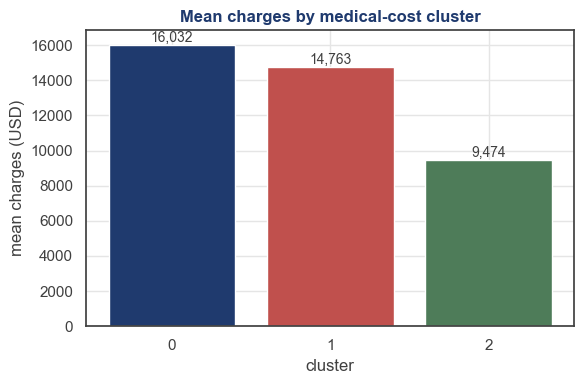

,age,bmi,children,sex,smoker,region,mean_charges
0,52.73,31.48,0.44,female,no,southeast,16032.0
1,40.49,30.96,2.66,male,no,northwest,14763.0
2,25.51,29.66,0.44,male,no,southeast,9474.0


In [41]:
# Exercise 5 continued — refit at your chosen K, then interpret + visualise
K_EX = 3
km_med = KMeans(n_clusters=K_EX, n_init=10, random_state=SEED).fit(X_med_scaled)
labels_med = km_med.labels_

# Back-transform numeric centroids; read off categorical modes per cluster.
num_scaler_med = preprocess_med.named_transformers_["num"]
centroid_num_med = pd.DataFrame(
    num_scaler_med.inverse_transform(km_med.cluster_centers_[:, :len(num_med)]),
    columns=num_med,
)
centroid_cat_med = pd.DataFrame({
    col: [X_med.loc[labels_med == k, col].mode().iloc[0] for k in range(K_EX)]
    for col in cat_med
})
mean_charges = df_med.assign(cluster=labels_med).groupby("cluster")[target_med].mean().round(0)

# Bar chart of mean charges per cluster — the actuarial payoff at a glance.
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(mean_charges.index.astype(str), mean_charges.values,
              color=[PRIMARY, ACCENT_RED, ACCENT_GREEN][:K_EX], edgecolor="white")
for b, v in zip(bars, mean_charges.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,.0f}", ha="center", va="bottom",
            color=GRAY_TEXT, fontsize=10)
ax.set_xlabel("cluster"); ax.set_ylabel("mean charges (USD)")
ax.set_title("Mean charges by medical-cost cluster")
fig.tight_layout()
plt.show()

pd.concat([centroid_num_med.round(2), centroid_cat_med,
           mean_charges.rename("mean_charges")], axis=1)

In [42]:
# Solution — the smoker / high-BMI segment carries the medical-cost signal
# With K = 3 the dominant split is smoker vs non-smoker; the smoker cluster
# further splits on BMI. The high-cost cluster is "smokers with high BMI".
high_cost_cluster = int(mean_charges.idxmax())
mask = labels_med == high_cost_cluster
print(f"Highest-charges cluster: {high_cost_cluster}  (mean charges {mean_charges.loc[high_cost_cluster]:,.0f})")
print(f"  smoker mode: {X_med.loc[mask, 'smoker'].mode().iloc[0]}")
print(f"  mean BMI:    {X_med.loc[mask, 'bmi'].mean():.1f}")
print(f"  mean age:    {X_med.loc[mask, 'age'].mean():.1f}")

Highest-charges cluster: 0  (mean charges 16,032)
  smoker mode: no
  mean BMI:    31.5
  mean age:    52.7


## Summary

- **Linear regression** shines when the relationship is roughly linear and you need interpretable coefficients. On the medical-cost dataset it explained ~78 % of the variance with one coefficient per feature.
- **Logistic regression** is the default first move for a probability task: calibrated probabilities, coefficients as log-odds. On the car-insurance dataset it reached AUC ≈ 0.92 and a coefficient ranking that matches motor-actuarial intuition (driving experience and vehicle attributes leading).
- **Decision trees** capture non-linearities and interactions for free; they handle mixed feature types gracefully and produce a *flow-chart of if-then rules* that an underwriter can read directly. Their probabilities are not believable beyond a shallow depth, and a single tree is unstable.
- **K-means** turns an unlabelled portfolio into a small set of named segments quickly; it requires a choice of K and assumes roughly spherical clusters.

The big pedagogical bridge to Section 2: ensembles (Random Forest, CatBoost) keep the tree's ability to discover non-linearities *and* recover the calibration that ruined the single tree's probabilities.

## Next steps

Continue with [Section 2 — Modern Machine Learning Techniques](../02_modern_ml_techniques/02_modern_ml_techniques.ipynb), where regularised GLMs, Random Forests, gradient boosting, small neural networks, and agglomerative hierarchical clustering pick up where these four classical methods stop.


## References

- *Medical Cost Personal Datasets* — M. Choi, Kaggle, 2018: <https://www.kaggle.com/datasets/mirichoi0218/insurance>. Used here for non-commercial education.
- *Car Insurance Data* — Kaggle (sagnik1511): <https://www.kaggle.com/datasets/sagnik1511/car-insurance-data> (10,000 rows, target `OUTCOME` ∈ {0, 1}). Used here for non-commercial education.
- Pedregosa et al., *scikit-learn: Machine Learning in Python*, JMLR 12, 2011 — <https://scikit-learn.org/stable/>.
- Hastie, Tibshirani & Friedman, *The Elements of Statistical Learning* (2nd ed.), Springer, 2009 — chapters 3 (linear), 4 (logistic), 9 (trees), 14 (k-means). Free PDF from the authors: <https://hastie.su.domains/ElemStatLearn/>.
- James, Witten, Hastie & Tibshirani, *An Introduction to Statistical Learning* — a gentler companion, free at <https://www.statlearning.com/>.
- Niculescu-Mizil & Caruana, *Predicting Good Probabilities With Supervised Learning*, ICML 2005 — why tree-based models miscalibrate.

---

Part of the EAA seminar *Machine Learning & Generative AI: A Hands-On Guide to Actuarial Practice* by Dr. Simon Hatzesberger. Code under the MIT License — see [LICENSE](https://github.com/simonhatzesberger/ml-genai-actuarial-practice/blob/main/LICENSE).
